# ED408 — Statistical Machine Learning II Lab
## Experiment 5: PCA and t-SNE for 2-D visualisation
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 5 — PCA and t-SNE (2-D structure of pixels, in place of MNIST digits)

We project the standardised, log-transformed 17-D filter space to 2-D. Expectation: strong low-dimensional structure (multi-scale filters are redundant — every filter responds to the same physical edges) but only partial class separation, because boundaries are defined by *human perception*, not by any single filter.

In [2]:
from sklearn.metrics import roc_auc_score
# helper (shared with Lab 3): signed log transform for heavy-tailed filter responses
def slog(x):
    return np.sign(x) * np.log1p(np.abs(x))

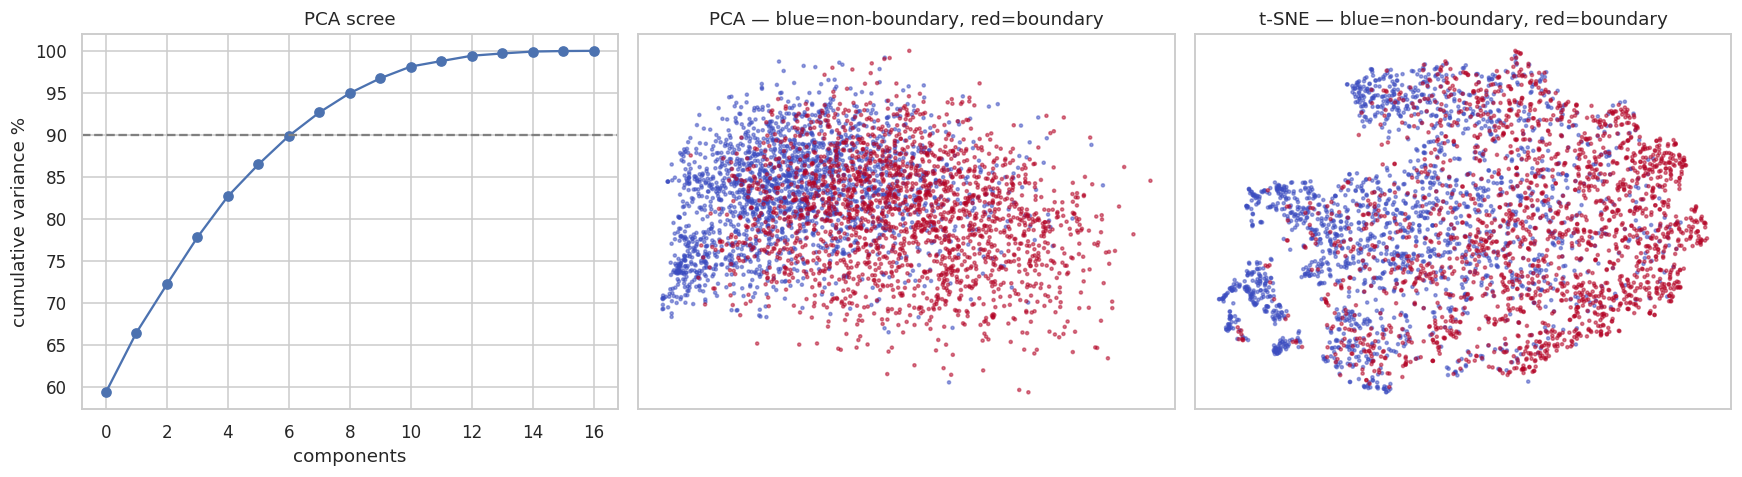

PC1+PC2 explain 66.4% of variance; 90% needs 8 components


In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_viz = slog(np.vstack([X_tr, X_te]))
y_viz = np.hstack([y_tr, y_te])
X_viz = (X_viz - X_viz.mean(0)) / (X_viz.std(0) + 1e-12)

pca_full = PCA().fit(X_viz)
evr = pca_full.explained_variance_ratio_

idx = np.hstack([RNG.choice(np.where(y_viz==c)[0], 2000, replace=False) for c in (0,1)])  # balanced sample for plots
P2 = PCA(n_components=2).fit_transform(X_viz)[idx]
T2 = TSNE(n_components=2, perplexity=40, init="pca", random_state=42).fit_transform(X_viz[idx])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(np.cumsum(evr)*100, "o-"); ax[0].axhline(90, ls="--", c="gray")
ax[0].set(xlabel="components", ylabel="cumulative variance %", title="PCA scree")
for a, E, name in [(ax[1], P2, "PCA"), (ax[2], T2, "t-SNE")]:
    a.scatter(*E.T, c=y_viz[idx], cmap="coolwarm", s=4, alpha=.5)
    a.set(title=f"{name} — blue=non-boundary, red=boundary", xticks=[], yticks=[])
plt.tight_layout(); plt.show()
print(f"PC1+PC2 explain {evr[:2].sum()*100:.1f}% of variance; 90% needs {np.searchsorted(np.cumsum(evr), .9)+1} components")

**Observations.** The scree plot quantifies the redundancy of multi-scale filter banks: a handful of components carry most of the variance because every filter responds to the same underlying edges. In the t-SNE map, boundary pixels concentrate along a high-energy manifold but bleed into textured non-boundary regions — precisely the pixels where gradient-based edge detectors classically fail and human annotators disagree.